**Python Notebook 1 – Data Understanding and Preprocessing**

Module: 5DATA002W.2 – Machine Learning & Data Mining

Author: Shane Rowell

Peer Reviewer: Dasika Ruvishan

Review Date: 13/03/2026

Dataset: loan_approval_data.csv

**Step 1 – Import Libraries**

In [ ]:
# Import pandas for data manipulation and analysis
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib for plotting graphs
import matplotlib.pyplot as plt

# Import seaborn for statistical visualisation
import seaborn as sns

# Import LabelEncoder to convert categorical text into numerical form
from sklearn.preprocessing import LabelEncoder

**Step 2 – Load Dataset**

In [ ]:
# Load the dataset from CSV into a pandas DataFrame
df = pd.read_csv('loan_approval_data.csv')

# Display the first 5 rows to confirm the data loaded correctly
df.head()

,id,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,35437,21.0,12000,OWN,0,EDUCATION,15000,6.99,0.12,N,4,0,-2426900
1,53756,21.0,13200,OWN,2,EDUCATION,25000,16.77,0.19,Y,3,0,-111739
2,42205,23.0,9600,RENT,5,MEDICAL,30000,12.42,0.31,N,3,0,-89000
3,19180,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,0,35000
4,28072,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,0,35000


**Step 3 – Data Understanding**

Step 3a – Dataset Dimensions

In [ ]:
# Display the number of rows and columns in the dataset
print("Dataset Dimensions (rows, columns):", df.shape)

Dataset Dimensions (rows, columns): (58645, 13)


Step 3b – Column Names and Data Types

In [ ]:
# Display column names, non-null counts and data types for each feature
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       58645 non-null  int64  
 1   age                      58639 non-null  float64
 2   income                   58645 non-null  int64  
 3   home_ownership           58645 non-null  object 
 4   emplyment_length         58645 non-null  int64  
 5   loan_intent              58645 non-null  object 
 6   loan_amount              58645 non-null  int64  
 7   loan_interest_rate       58634 non-null  float64
 8   loan_income_ratio        58645 non-null  float64
 9   payment_default_on_file  58640 non-null  object 
 10  credit_history_length    58645 non-null  int64  
 11  loan_approval_status     58645 non-null  int64  
 12  max_allowed_loan         58645 non-null  int64  
dtypes: float64(3), int64(7), object(3)
memory usage: 5.8+ MB


Step 3c – Statistical Summary

In [ ]:
# Display statistical summary including mean, std, min, max and quartiles
df.describe()

,id,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,loan_approval_status,max_allowed_loan
count,58645.000000,58639.000000,5.864500e+04,58645.000000,58645.000000,58634.000000,58645.000000,58645.000000,58645.000000,5.864500e+04
mean,29322.000000,27.550913,6.404617e+04,4.703487,9217.556518,10.677526,0.159238,5.813556,0.142382,6.975472e+04
std,16929.497605,6.033217,3.793111e+04,4.004982,5563.807384,3.036034,0.091692,4.029196,0.349445,6.175091e+04
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,-11.140000,0.000000,2.000000,0.000000,-2.426900e+06
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000,3.800300e+04
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000,6.239200e+04
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000,9.271600e+04
max,58644.000000,123.000000,1.900000e+06,150.000000,35000.000000,23.220000,0.830000,30.000000,1.000000,2.638778e+06


Step 3d – Missing Value Analysis

In [ ]:
# Count the number of missing values per column
missing = df.isnull().sum()

# Calculate the percentage of missing values per column
missing_pct = (missing / len(df)) * 100

# Combine into a summary table
missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})

# Show only columns that have at least one missing value
print(missing_summary[missing_summary['Missing Count'] > 0])

                         Missing Count  Missing %
age                                  6       0.01
loan_interest_rate                  11       0.02
payment_default_on_file              5       0.01


Step 3e – Target Variable Distribution for Classification

*Note: In this dataset loan_approval_status = 0 means Approved and = 1 means Rejected*

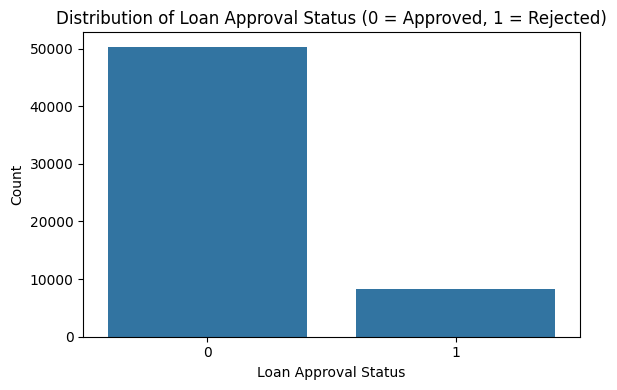

loan_approval_status
0    50295
1     8350
Name: count, dtype: int64

Class proportions:
loan_approval_status
0    0.858
1    0.142
Name: proportion, dtype: float64


In [ ]:
# Plot the class distribution of the classification target variable
plt.figure(figsize=(6, 4))

# Count plot showing approved vs rejected loan counts
sns.countplot(x='loan_approval_status', data=df)

# Title and axis labels
# 0 = Approved, 1 = Rejected as per the spec data dictionary
plt.title('Distribution of Loan Approval Status (0 = Approved, 1 = Rejected)')
plt.xlabel('Loan Approval Status')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Print exact counts and class proportions
print(df['loan_approval_status'].value_counts())
print("\nClass proportions:")
print(df['loan_approval_status'].value_counts(normalize=True).round(3))

Step 3f – Target Variable Distribution for Regression

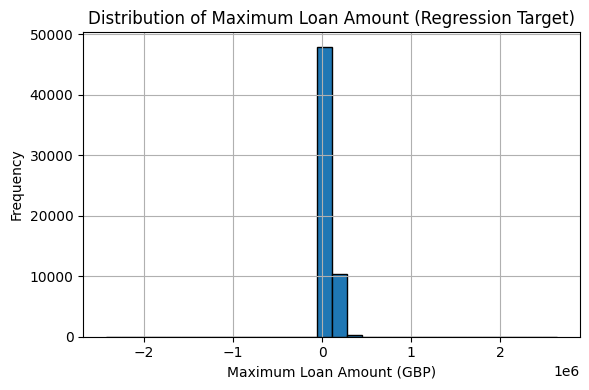

count    5.864500e+04
mean     6.975472e+04
std      6.175091e+04
min     -2.426900e+06
25%      3.800300e+04
50%      6.239200e+04
75%      9.271600e+04
max      2.638778e+06
Name: max_allowed_loan, dtype: float64


In [ ]:
# Plot the distribution of the regression target variable
plt.figure(figsize=(6, 4))

# Histogram showing the spread of maximum loan amounts
# Only approved clients have a valid max_allowed_loan value
df['max_allowed_loan'].dropna().hist(bins=30, edgecolor='black')

# Title and axis labels
plt.title('Distribution of Maximum Loan Amount (Regression Target)')
plt.xlabel('Maximum Loan Amount (GBP)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Print summary statistics for the regression target
print(df['max_allowed_loan'].describe())

**Step 4 – Data Cleaning and Preparation**

Step 4a – Handle Missing Values

In [ ]:
# Impute missing age values with the column mean
df['age'] = df['age'].fillna(df['age'].mean())

# Impute missing loan interest rate with the column mean
df['loan_interest_rate'] = df['loan_interest_rate'].fillna(df['loan_interest_rate'].mean())

# Impute missing loan-to-income ratio with the column mean
df['loan_income_ratio'] = df['loan_income_ratio'].fillna(df['loan_income_ratio'].mean())

# Impute missing credit history length with the column mean
df['credit_history_length'] = df['credit_history_length'].fillna(df['credit_history_length'].mean())

# Impute missing employment length with the column mean
df['emplyment_length'] = df['emplyment_length'].fillna(df['emplyment_length'].mean())

# Impute missing income values with the column mean
df['income'] = df['income'].fillna(df['income'].mean())

# Impute missing loan amount values with the column mean
df['loan_amount'] = df['loan_amount'].fillna(df['loan_amount'].mean())

# Impute missing home ownership values with the most frequent category
df['home_ownership'] = df['home_ownership'].fillna(df['home_ownership'].mode()[0])

# Impute missing loan intent values with the most frequent category
df['loan_intent'] = df['loan_intent'].fillna(df['loan_intent'].mode()[0])

# Impute missing payment default status with the most frequent category
df['payment_default_on_file'] = df['payment_default_on_file'].fillna(df['payment_default_on_file'].mode()[0])

# Confirm all missing values have been resolved
print("Remaining missing values after imputation:")
print(df.isnull().sum())
print("\nTotal remaining NaNs:", df.isnull().sum().sum())

Remaining missing values after imputation:
id                         0
age                        0
income                     0
home_ownership             0
emplyment_length           0
loan_intent                0
loan_amount                0
loan_interest_rate         0
loan_income_ratio          0
payment_default_on_file    0
credit_history_length      0
loan_approval_status       0
max_allowed_loan           0
dtype: int64

Total remaining NaNs: 0


Step 4b – Encode Categorical Variables

*LabelEncoder converts text category values into integer form so machine learning algorithms can process them.*

In [ ]:
# Create a LabelEncoder instance
le = LabelEncoder()

# Encode home ownership categories into integers
df['home_ownership'] = le.fit_transform(df['home_ownership'])

# Encode loan intent categories into integers
df['loan_intent'] = le.fit_transform(df['loan_intent'])

# Encode payment default on file into integers
df['payment_default_on_file'] = le.fit_transform(df['payment_default_on_file'])

# Display the first 5 rows to confirm encoding applied correctly
df.head()

,id,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,35437,21.0,12000,2,0,1,15000,6.99,0.12,0,4,0,-2426900
1,53756,21.0,13200,2,2,1,25000,16.77,0.19,1,3,0,-111739
2,42205,23.0,9600,3,5,3,30000,12.42,0.31,0,3,0,-89000
3,19180,40.0,182004,3,3,1,35000,8.00,0.19,0,11,0,35000
4,28072,40.0,90000,0,3,2,35000,12.42,0.39,0,14,0,35000


**Step 5 – Create Classification Dataset**

In [ ]:
# Create the classification dataset by removing non-predictive and leakage columns
df_classification = df.drop(columns=['id', 'max_allowed_loan'], errors='ignore')

# Display the retained columns
print("Classification Dataset Columns:")
print(df_classification.columns.tolist())

# Display the dataset dimensions
print("\nClassification Dataset Shape:", df_classification.shape)

# Confirm no missing values remain
print("\nMissing values:", df_classification.isnull().sum().sum())

# Preview the final classification dataset
df_classification.head()

Classification Dataset Columns:
['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'loan_approval_status']

Classification Dataset Shape: (58645, 11)

Missing values: 0


,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
0,21.0,12000,2,0,1,15000,6.99,0.12,0,4,0
1,21.0,13200,2,2,1,25000,16.77,0.19,1,3,0
2,23.0,9600,3,5,3,30000,12.42,0.31,0,3,0
3,40.0,182004,3,3,1,35000,8.00,0.19,0,11,0
4,40.0,90000,0,3,2,35000,12.42,0.39,0,14,0


**Step 6 – Create Regression Dataset**

In [ ]:
# Filter to approved loans only
# In this dataset loan_approval_status = 0 means Approved
df_regression = df[df['loan_approval_status'] == 0].copy()

# Remove rows where max_allowed_loan is negative as these are data entry errors
df_regression = df_regression[df_regression['max_allowed_loan'] > 0].copy()

# Drop id and loan_approval_status as they are not useful features for regression
df_regression = df_regression.drop(columns=['id', 'loan_approval_status'], errors='ignore')

# Display the retained columns
print("Regression Dataset Columns:")
print(df_regression.columns.tolist())

# Display the dataset dimensions
print("\nRegression Dataset Shape:", df_regression.shape)

# Confirm no missing values remain
print("\nMissing values:", df_regression.isnull().sum().sum())

# Preview the final regression dataset
df_regression.head()

Regression Dataset Columns:
['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'max_allowed_loan']

Regression Dataset Shape: (50292, 11)

Missing values: 0


,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,max_allowed_loan
3,40.0,182004,3,3,1,35000,8.00,0.19,0,11,35000
4,40.0,90000,0,3,2,35000,12.42,0.39,0,14,35000
5,40.0,131004,0,9,5,30000,7.90,0.23,0,13,30000
6,40.0,150000,0,9,0,25000,11.89,0.17,0,11,25000
7,40.0,132000,0,3,2,25000,16.82,0.22,0,17,25000


**Step 7 – Final Verification**

In [ ]:
# Print final summary for the classification dataset
print("=" * 50)
print("CLASSIFICATION DATASET – FINAL SUMMARY")
print("=" * 50)
print("Shape:", df_classification.shape)
print("\nData types:")
print(df_classification.dtypes)
print("\nClass distribution:")
print(df_classification['loan_approval_status'].value_counts())

# Print final summary for the regression dataset
print("\n" + "=" * 50)
print("REGRESSION DATASET – FINAL SUMMARY")
print("=" * 50)
print("Shape:", df_regression.shape)
print("\nData types:")
print(df_regression.dtypes)
print("\nTarget variable stats:")
print(df_regression['max_allowed_loan'].describe())

CLASSIFICATION DATASET – FINAL SUMMARY
Shape: (58645, 11)

Data types:
age                        float64
income                       int64
home_ownership               int64
emplyment_length             int64
loan_intent                  int64
loan_amount                  int64
loan_interest_rate         float64
loan_income_ratio          float64
payment_default_on_file      int64
credit_history_length        int64
loan_approval_status         int64
dtype: object

Class distribution:
loan_approval_status
0    50295
1     8350
Name: count, dtype: int64

REGRESSION DATASET – FINAL SUMMARY
Shape: (50292, 11)

Data types:
age                        float64
income                       int64
home_ownership               int64
emplyment_length             int64
loan_intent                  int64
loan_amount                  int64
loan_interest_rate         float64
loan_income_ratio          float64
payment_default_on_file      int64
credit_history_length        int64
max_allowed_loan      

Peer Code Review Record
Code Reuse Session 1 – Data Understanding and Preparation (Week 3)

Notebook Author: Shane Rowell
Peer Reviewer: Dasika Ruvishan
Date of Review: 14/03/2026

Tests checked during peer review:

- Test 1: Dasika verified that all missing values were handled correctly
  across all columns and confirmed that the total remaining NaN count is 0
  after imputation.

- Test 2: Dasika confirmed that the non-predictive column id and the data
  leakage column max_allowed_loan were successfully removed from the
  classification dataset and are not present in df_classification.

- Test 3: Dasika confirmed that the regression dataset df_regression contains
  only approved loan records where loan_approval_status equals 0 and that
  negative max_allowed_loan values were removed, and that both final datasets
  have the correct expected shapes and column structures.